In [1]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from mne.decoding import CSP
import mne
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import sys
import os
#import mlflow
#import mlflow.sklearn

sys.path.append(os.path.abspath(os.path.join('..')))

from src.train_CSP import train_CSP
from src.load_data_BCICIV import load_all_subjects
from src.preprocess import normalize_trial

np.random.seed(42)

mne.set_log_level('WARNING')

/home/alumno/Desktop/datos/nn/EEGNet-Motor-Imagery-BCI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## LOAD TRAIN DATA FOR BCICIV DATASET

In [2]:
data_path = '../datasets/BCICIV_2a_gdf'

data_22 = load_all_subjects(data_path, channels_to_use='all')
data_22_multiband = load_all_subjects(data_path, use_multiband=True, bands=[(8, 12), (13, 30)], channels_to_use='all')
data_11 = load_all_subjects(data_path)
data_11_multiband = load_all_subjects(data_path, use_multiband=True, bands=[(8, 12), (13, 30)])

/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A01T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A02T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A08T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A09T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-l

In [3]:
subjects = data_22['subject_ids'] 

X_22 = data_22['X'] 
y_22 = data_22['y'] 

X_22_multiband = data_22_multiband['X'] 
y_22_multiband = data_22_multiband['y'] 

X_11 = data_11['X'] 
y_11 = data_11['y'] 

X_11_multiband = data_11_multiband['X'] 
y_11_multiband = data_11_multiband['y'] 

In [4]:
X_22_mu = np.copy(X_22_multiband[:, 0, :, :])

X_11_mu = np.copy(X_11_multiband[:, 0, :, :])

trials, bands, channels, samples = X_22_multiband.shape
X_22_mu_beta = np.copy(X_22_multiband).reshape(trials, bands*channels, samples)


trials, bands, channels, samples = X_11_multiband.shape
X_11_mu_beta = np.copy(X_11_multiband).reshape(trials, bands*channels, samples)

In [5]:
models = {
    'model': [],
    'score': [],
    'name': []
}

# 22 channels (raw + normalization)

## CSP + LDA MODEL

In [6]:
norm_transformer = FunctionTransformer(normalize_trial)

def to_float64(X):
    return X.astype(np.float64)

to_float64 = FunctionTransformer(to_float64)


In [7]:
pipe1 = Pipeline([
    ('to_float64', to_float64),
    ('norm', norm_transformer),
    ('csp', CSP(log=True, norm_trace=False)),
    ('clf', LinearDiscriminantAnalysis())
])

param_grid1 = {
    'csp__n_components': [2, 4],
    'csp__reg': ['ledoit_wolf', 'oas'],
    'clf__solver': ['svd', 'lsqr']
}

In [8]:
model, params, best_score = train_CSP(X_22, y_22, subjects, pipe1, param_grid1, '22_ch_raw_LDA')
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('22_ch_raw_LDA')


 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.5951 | Val Acc = 0.5315
Subject A02: Train Acc = 0.5817 | Val Acc = 0.5694
Subject A03: Train Acc = 0.6061 | Val Acc = 0.4653
Subject A04: Train Acc = 0.6047 | Val Acc = 0.5245
Subject A05: Train Acc = 0.5843 | Val Acc = 0.5069
Subject A06: Train Acc = 0.6000 | Val Acc = 0.4861
Subject A07: Train Acc = 0.5478 | Val Acc = 0.5069
Subject A08: Train Acc = 0.6096 | Val Acc = 0.4792


2026/03/10 11:59:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/10 11:59:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Subject A09: Train Acc = 0.5983 | Val Acc = 0.5069


2026/03/10 11:59:18 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Best score: 0.508530821030821


## CSP + SVM MODEL

In [9]:
pipe2 = Pipeline([
    ('to_float64', to_float64),
    ('norm', norm_transformer),
    ('csp', CSP(log=True, norm_trace=False)),
    ('clf', SVC(kernel='rbf'))
])

param_grid2 = {
    'csp__n_components': [2, 4],
    'csp__reg': ['ledoit_wolf', 'oas'],
    'clf__C': [0.5, 1, 5],
    'clf__gamma': ['scale']
}

In [10]:
model, params, best_score = train_CSP(X_22, y_22, subjects, pipe2, param_grid2, '22_ch_raw_SVM')
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('22_ch_raw_SVM')


 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.6030 | Val Acc = 0.5594
Subject A02: Train Acc = 0.6017 | Val Acc = 0.5556
Subject A03: Train Acc = 0.6200 | Val Acc = 0.4931
Subject A04: Train Acc = 0.6064 | Val Acc = 0.5315
Subject A05: Train Acc = 0.6096 | Val Acc = 0.5139
Subject A06: Train Acc = 0.5983 | Val Acc = 0.4861
Subject A07: Train Acc = 0.5687 | Val Acc = 0.5000
Subject A08: Train Acc = 0.6252 | Val Acc = 0.4722


2026/03/10 12:05:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/10 12:05:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Subject A09: Train Acc = 0.6278 | Val Acc = 0.5000


2026/03/10 12:05:18 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Best score: 0.5124158249158248


# 22 channels (only mu band)

## CSP + LDA MODEL

In [11]:
model, params, best_score = train_CSP(X_22_mu, y_22_multiband, subjects, pipe1, param_grid1, '22_ch_mu_LDA')
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('22_ch_mu_LDA')

2026/03/10 12:08:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.5673 | Val Acc = 0.5245
Subject A02: Train Acc = 0.5739 | Val Acc = 0.5417
Subject A03: Train Acc = 0.5678 | Val Acc = 0.4653
Subject A04: Train Acc = 0.5778 | Val Acc = 0.5035
Subject A05: Train Acc = 0.5635 | Val Acc = 0.4722
Subject A06: Train Acc = 0.5513 | Val Acc = 0.5000
Subject A07: Train Acc = 0.5661 | Val Acc = 0.5000
Subject A08: Train Acc = 0.5522 | Val Acc = 0.4861
Subject A09: Train Acc = 0.5757 | Val Acc = 0.5069


2026/03/10 12:08:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/10 12:08:54 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Best score: 0.5000215833549168


## CSP + SVM MODEL

In [12]:
model, params, best_score = train_CSP(X_22_mu, y_22_multiband, subjects, pipe2, param_grid2, '22_ch_mu_SVM')
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('22_ch_mu_SVM')


 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.5699 | Val Acc = 0.5315
Subject A02: Train Acc = 0.5678 | Val Acc = 0.5000
Subject A03: Train Acc = 0.5670 | Val Acc = 0.4792
Subject A04: Train Acc = 0.5717 | Val Acc = 0.5664
Subject A05: Train Acc = 0.5800 | Val Acc = 0.4722
Subject A06: Train Acc = 0.5574 | Val Acc = 0.4861
Subject A07: Train Acc = 0.5748 | Val Acc = 0.5139


2026/03/10 12:14:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/10 12:14:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Subject A08: Train Acc = 0.5522 | Val Acc = 0.4861
Subject A09: Train Acc = 0.5826 | Val Acc = 0.4931


2026/03/10 12:14:52 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Best score: 0.5031619614952948


# 22 channels (mu + beta band)

## CSP + LDA MODEL

In [13]:
model, params, best_score = train_CSP(X_22_mu_beta, y_22_multiband, subjects, pipe1, param_grid1, '22_ch_mu_beta_LDA')
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('22_ch_mu_beta_LDA')


 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.5708 | Val Acc = 0.5804
Subject A02: Train Acc = 0.5774 | Val Acc = 0.5000
Subject A03: Train Acc = 0.5704 | Val Acc = 0.4653
Subject A04: Train Acc = 0.5760 | Val Acc = 0.5524
Subject A05: Train Acc = 0.5678 | Val Acc = 0.5556
Subject A06: Train Acc = 0.5661 | Val Acc = 0.4861
Subject A07: Train Acc = 0.5713 | Val Acc = 0.5347
Subject A08: Train Acc = 0.5809 | Val Acc = 0.4653


2026/03/10 12:24:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/10 12:24:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Subject A09: Train Acc = 0.5930 | Val Acc = 0.5139


2026/03/10 12:24:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Best score: 0.5170778295778297


## CSP + SVM MODEL

In [14]:
model, params, best_score = train_CSP(X_22_mu_beta, y_22_multiband, subjects, pipe2, param_grid2, '22_ch_mu_beta_SVM')
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('22_ch_mu_beta_SVM')

2026/03/10 12:38:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.6047 | Val Acc = 0.5245
Subject A02: Train Acc = 0.6078 | Val Acc = 0.5139
Subject A03: Train Acc = 0.6061 | Val Acc = 0.4514
Subject A04: Train Acc = 0.6012 | Val Acc = 0.5105
Subject A05: Train Acc = 0.6009 | Val Acc = 0.5486
Subject A06: Train Acc = 0.6313 | Val Acc = 0.4514
Subject A07: Train Acc = 0.6165 | Val Acc = 0.5556
Subject A08: Train Acc = 0.5765 | Val Acc = 0.4861
Subject A09: Train Acc = 0.6261 | Val Acc = 0.5208


2026/03/10 12:38:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/10 12:38:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Best score: 0.5069714236380903


# 11 channels (raw + normalization)

## CSP + LDA MODEL

In [15]:
model, params, best_score = train_CSP(X_11, y_11, subjects, pipe1, param_grid1, '11_ch_raw_LDA')
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('11_ch_raw_LDA')

2026/03/10 12:40:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.5387 | Val Acc = 0.5804
Subject A02: Train Acc = 0.5435 | Val Acc = 0.4931
Subject A03: Train Acc = 0.5617 | Val Acc = 0.4028
Subject A04: Train Acc = 0.5421 | Val Acc = 0.5035
Subject A05: Train Acc = 0.5861 | Val Acc = 0.6042
Subject A06: Train Acc = 0.5530 | Val Acc = 0.5000
Subject A07: Train Acc = 0.5383 | Val Acc = 0.4167
Subject A08: Train Acc = 0.5409 | Val Acc = 0.5069
Subject A09: Train Acc = 0.5461 | Val Acc = 0.5069


2026/03/10 12:40:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/10 12:40:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Best score: 0.5016079599412933


## CSP + SVM MODEL

In [16]:
model, params, best_score = train_CSP(X_11, y_11, subjects, pipe2, param_grid2, '11_ch_raw_SVM')
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('11_ch_raw_SVM')


 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.6229 | Val Acc = 0.5804
Subject A02: Train Acc = 0.6383 | Val Acc = 0.5139
Subject A03: Train Acc = 0.6191 | Val Acc = 0.5000
Subject A04: Train Acc = 0.6160 | Val Acc = 0.5035
Subject A05: Train Acc = 0.6296 | Val Acc = 0.5139
Subject A06: Train Acc = 0.6374 | Val Acc = 0.5556
Subject A07: Train Acc = 0.5957 | Val Acc = 0.5278
Subject A08: Train Acc = 0.6548 | Val Acc = 0.5417


2026/03/10 12:43:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/10 12:43:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Subject A09: Train Acc = 0.6287 | Val Acc = 0.5208


2026/03/10 12:43:10 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Best score: 0.5286141327807994


# 11 channels (only mu band)

## CSP + LDA MODEL

In [17]:
model, params, best_score = train_CSP(X_11_mu, y_11_multiband, subjects, pipe1, param_grid1, '11_ch_mu_LDA')
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('11_ch_mu_LDA')


 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.5604 | Val Acc = 0.5594
Subject A02: Train Acc = 0.5635 | Val Acc = 0.5139
Subject A03: Train Acc = 0.5565 | Val Acc = 0.4583
Subject A04: Train Acc = 0.5439 | Val Acc = 0.4895
Subject A05: Train Acc = 0.5374 | Val Acc = 0.3889
Subject A06: Train Acc = 0.5400 | Val Acc = 0.4861
Subject A07: Train Acc = 0.5513 | Val Acc = 0.5139
Subject A08: Train Acc = 0.5322 | Val Acc = 0.4931
Subject A09: Train Acc = 0.5443 | Val Acc = 0.5069


2026/03/10 12:44:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/10 12:44:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/10 12:44:52 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Best score: 0.49000690667357344


## CSP + SVM MODEL

In [18]:
model, params, best_score = train_CSP(X_11_mu, y_11_multiband, subjects, pipe2, param_grid2, '11_ch_mu_SVM')
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('11_ch_mu_SVM')

2026/03/10 12:47:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.6142 | Val Acc = 0.5664
Subject A02: Train Acc = 0.6148 | Val Acc = 0.5069
Subject A03: Train Acc = 0.6139 | Val Acc = 0.4792
Subject A04: Train Acc = 0.6264 | Val Acc = 0.4615
Subject A05: Train Acc = 0.6191 | Val Acc = 0.5694
Subject A06: Train Acc = 0.6348 | Val Acc = 0.5417
Subject A07: Train Acc = 0.6087 | Val Acc = 0.5000
Subject A08: Train Acc = 0.6104 | Val Acc = 0.5139
Subject A09: Train Acc = 0.6043 | Val Acc = 0.5069


2026/03/10 12:47:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/10 12:47:31 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Best score: 0.5162252870586204


# 11 channels (mu + beta band)

## CSP + LDA MODEL

In [19]:
model, params, best_score = train_CSP(X_11_mu_beta, y_11_multiband, subjects, pipe1, param_grid1, '11_ch_mu_beta_LDA')
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('11_ch_mu_beta_LDA')


 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.5673 | Val Acc = 0.5944
Subject A02: Train Acc = 0.5652 | Val Acc = 0.5694
Subject A03: Train Acc = 0.5565 | Val Acc = 0.4444
Subject A04: Train Acc = 0.5421 | Val Acc = 0.5175
Subject A05: Train Acc = 0.5748 | Val Acc = 0.5694
Subject A06: Train Acc = 0.5574 | Val Acc = 0.4444
Subject A07: Train Acc = 0.5748 | Val Acc = 0.5139
Subject A08: Train Acc = 0.5443 | Val Acc = 0.4931
Subject A09: Train Acc = 0.5522 | Val Acc = 0.5139


2026/03/10 12:51:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/10 12:51:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/10 12:51:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Best score: 0.5178332469999136


## CSP + SVM MODEL

In [20]:
model, params, best_score = train_CSP(X_11_mu_beta, y_11_multiband, subjects, pipe2, param_grid2, '11_ch_mu_beta_SVM')
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('11_ch_mu_beta_SVM')

2026/03/10 12:57:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.5969 | Val Acc = 0.4755
Subject A02: Train Acc = 0.5948 | Val Acc = 0.4861
Subject A03: Train Acc = 0.6157 | Val Acc = 0.4931
Subject A04: Train Acc = 0.5873 | Val Acc = 0.5385
Subject A05: Train Acc = 0.5878 | Val Acc = 0.6111
Subject A06: Train Acc = 0.5991 | Val Acc = 0.5417
Subject A07: Train Acc = 0.6052 | Val Acc = 0.5417
Subject A08: Train Acc = 0.6200 | Val Acc = 0.4653
Subject A09: Train Acc = 0.6148 | Val Acc = 0.5139


2026/03/10 12:57:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/10 12:57:17 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Best score: 0.5185293101959769


# Results

In [21]:
best_model_index = np.argmax(models['score'])
best_model = models['model'][best_model_index]
best_model_name = models['name'][best_model_index]
print(f"Best model: {best_model_name} with score {models['score'][best_model_index]}")

Best model: 11_ch_raw_SVM with score 0.5286141327807994


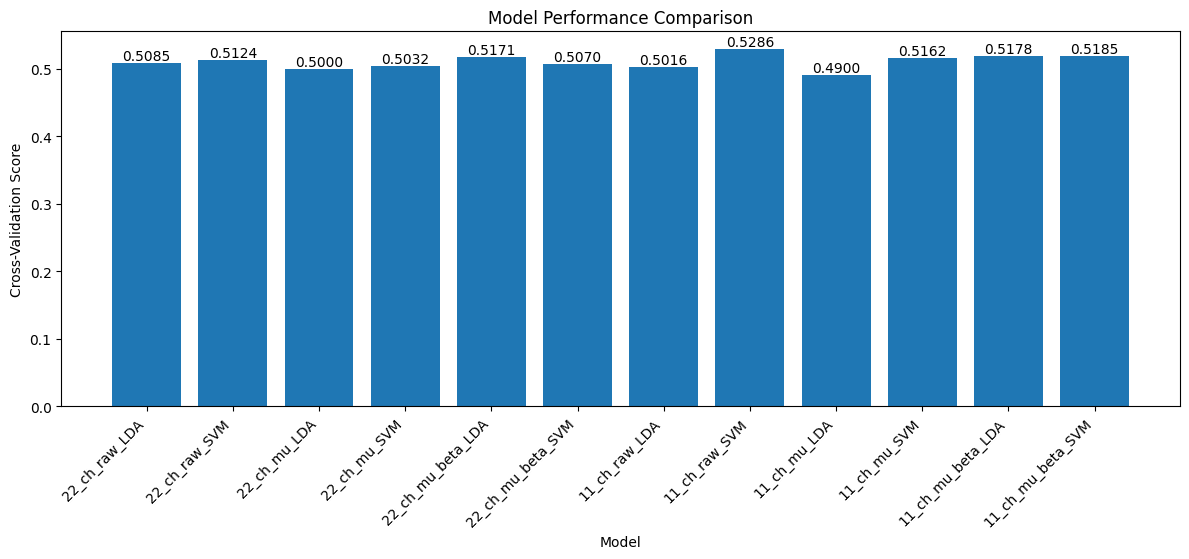

In [22]:
plt.figure(figsize=(12, 6))
bars = plt.bar(models['name'], models['score'])
plt.xlabel('Model')
plt.ylabel('Cross-Validation Score')
plt.title('Model Performance Comparison')
plt.bar_label(bars, fmt="%.4f")
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95],)

# Why not to try laplacian filter?

The Laplacian filter is a spatial filter that highlights local differences between electrodes. It is often applied over C3 and C4, where hand-movement activity is most clear. However, when using CSP, it usually does not improve model performance. This is because CSP finds linear combinations of all channels that maximize variance between classes while minimizing variance within each class. In other words, CSP already learns optimal spatial filters from the data, so the Laplacian filter is generally unnecessary.